In [7]:
import pandas as pd

df = pd.read_csv("/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [9]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


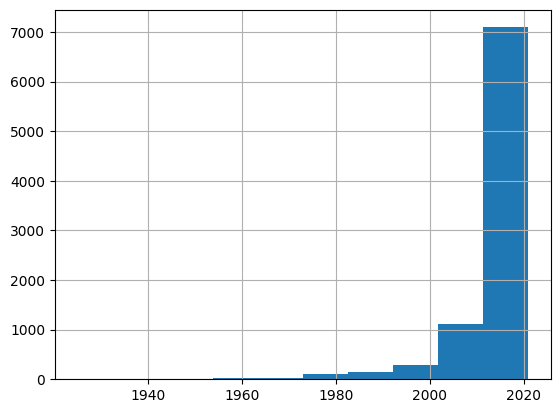

In [11]:
import matplotlib.pyplot as plt

df['release_year'].hist()
plt.show()

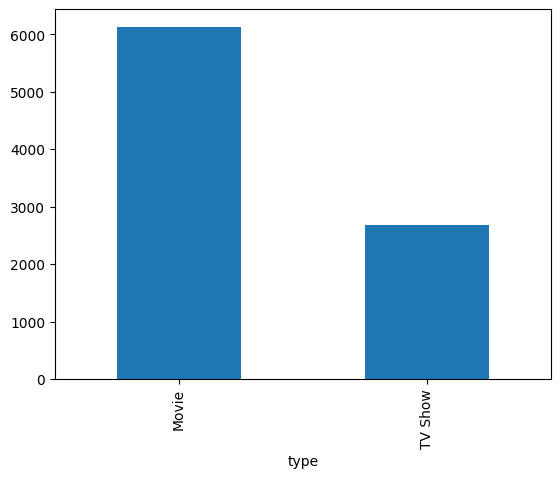

In [13]:
df['type'].value_counts().plot(kind='bar')
plt.show()

In [15]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('data', conn, index=False)

query = "SELECT type, COUNT(*) FROM data GROUP BY type"
pd.read_sql(query, conn)

,type,COUNT(*)
0,Movie,6131
1,TV Show,2676


In [16]:
query = """
SELECT type, COUNT(*) AS total_count
FROM data
GROUP BY type
ORDER BY total_count DESC
"""
result = pd.read_sql(query, conn)
print(result)

      type  total_count
0    Movie         6131
1  TV Show         2676


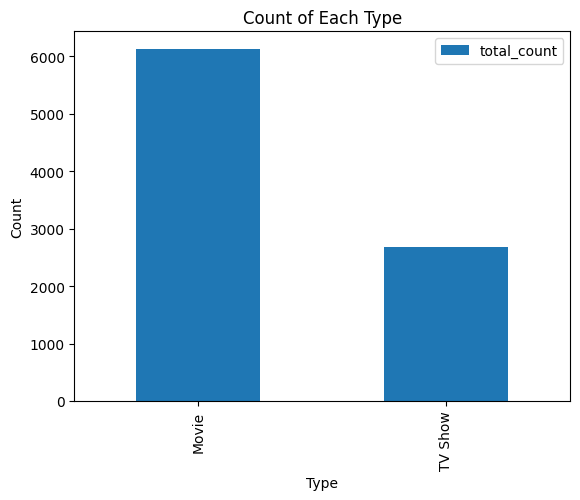

In [17]:
import matplotlib.pyplot as plt

result.plot(kind='bar', x='type', y='total_count')
plt.title("Count of Each Type")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

In [18]:
query = """
SELECT type, COUNT(*) AS count
FROM data
GROUP BY type
ORDER BY count DESC
LIMIT 5
"""
pd.read_sql(query, conn)

,type,count
0,Movie,6131
1,TV Show,2676


In [19]:
query = "SELECT COUNT(*) AS total_rows FROM data"
pd.read_sql(query, conn)

,total_rows
0,8807


In [20]:
query = "SELECT COUNT(DISTINCT type) AS unique_types FROM data"
pd.read_sql(query, conn)

,unique_types
0,2


In [22]:
query = "SELECT AVG(release_year) FROM data"
pd.read_sql(query, conn)

,AVG(release_year)
0,2014.180198


In [24]:
query = "SELECT MAX(release_year) FROM data"
pd.read_sql(query, conn)

,MAX(release_year)
0,2021


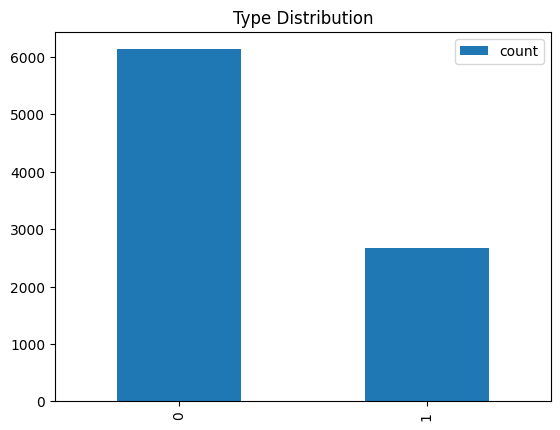

In [25]:
query = """
SELECT type, COUNT(*) as count
FROM data
GROUP BY type
"""
result = pd.read_sql(query, conn)

result.plot(kind='bar')
plt.title("Type Distribution")
plt.show()

In [26]:
pd.read_sql("SELECT COUNT(*) FROM data", conn)

,COUNT(*)
0,8807


In [27]:
pd.read_sql("SELECT COUNT(DISTINCT type) FROM data", conn)

,COUNT(DISTINCT type)
0,2


In [28]:
query = """
SELECT type, COUNT(*) as count
FROM data
GROUP BY type
ORDER BY count DESC
LIMIT 5
"""
pd.read_sql(query, conn)

,type,count
0,Movie,6131
1,TV Show,2676


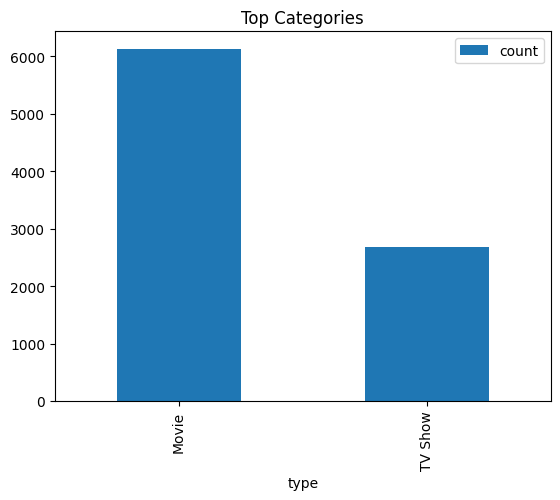

In [31]:
result = pd.read_sql(query, conn)

result.plot(kind='bar', x='type', y='count')
plt.title("Top Categories")
plt.show()

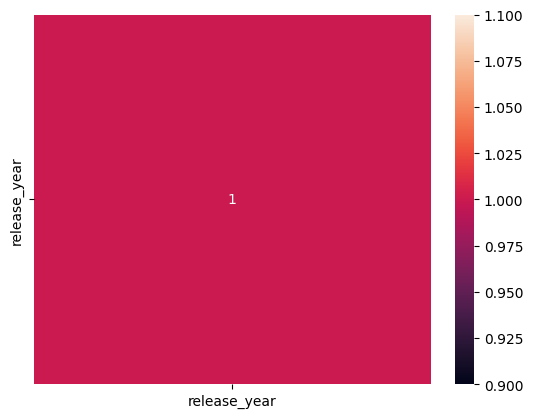

In [34]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()